# Model Evaluation: ROC Curve & AUC

## ROC and AUC

### ROC (Receiver Operating Characteristic)
- ROC is a **curve used to evaluate a classification model**.
- It shows how the model performs at **different threshold values**.
- **X-axis → False Positive Rate (FPR)**
- **Y-axis → True Positive Rate (TPR)**

### Simple Example: Spam Detection

Suppose a model predicts whether an email is Spam or Not Spam.

| Email | Actual | Probability |
|---|---|---:|
| A | Spam | 0.95 |
| B | Spam | 0.80 |
| C | Not Spam | 0.30 |
| D | Not Spam | 0.10 |

If the threshold is **0.5**:
- Probability ≥ 0.5 → Spam
- Probability < 0.5 → Not Spam

When we change the threshold (0.5, 0.6, 0.7, etc.), the **TPR and FPR change**.
The ROC curve plots these values.

---

### AUC (Area Under the Curve)

- AUC is the **area under the ROC curve**.
- It gives a single number representing how well the model can **distinguish between two classes**.

| AUC | Meaning |
|---:|---|
| 1.0 | Perfect model |
| 0.9 – 1.0 | Excellent |
| 0.8 – 0.9 | Very Good |
| 0.7 – 0.8 | Good |
| 0.6 – 0.7 | Weak/Moderate |
| 0.5 | Random guessing |
| < 0.5 | Worse than random |

### Important

**AUC > 0.5 → generally better than random**

But:
- AUC = **0.51** → only slightly better than random
- AUC = **0.75** → good
- AUC = **0.90** → excellent
- AUC = **1.00** → perfect

### Easy way to remember

> **ROC = Curve showing TPR vs FPR at different thresholds.**

> **AUC = Number showing how well the model separates the classes.**

**Higher AUC → Better class separation.**

<img width=1100 height=600 src="..\Datasets\ROC AUC.png" />

# Cost Benefit Analysis Using ROC in Sklearn

## ROC Threshold Selection

## 1. Get FPR, TPR and Thresholds

    fpr, tpr, thresholds = roc_curve(y_test, probabilities)

The three arrays are connected by the **same index**.

| Index | Threshold | FPR | TPR |
|---:|---:|---:|---:|
| 0 | `inf` | 0.000 | 0.000 |
| 1 | 0.9793 | 0.000 | 0.0078 |
| 2 | 0.8089 | 0.000 | 0.2656 |
| 3 | 0.8084 | 0.0082 | 0.2656 |
| 4 | 0.8021 | 0.0082 | 0.2891 |

For every threshold, the model calculates a different **TPR and FPR**.

---

## 2. Set the Desired Recall

    desired_recall = 0.9

We want the model to have approximately **90% recall**.

**Recall = TPR**

So we are looking for:

**TPR ≈ 0.90**

---

## 3. Find the Closest TPR

    closest_index = np.argmin(abs(tpr - desired_recall))

This works in 3 steps:

### Step 1: `tpr - desired_recall`

It compares every TPR value with `0.9`.

Example:

    TPR:        0.87    0.906    0.95
    Desired:    0.90    0.900    0.90

    Difference: 0.03    0.006    0.05

### Step 2: `abs(...)`

Converts the differences into positive values:

    0.03    0.006    0.05

### Step 3: `np.argmin(...)`

Finds the **index of the smallest difference**.

Therefore, it finds the TPR that is **closest to 0.9**.

---

## 4. Get the Values at That Index

    tpr[closest_index], thresholds[closest_index], fpr[closest_index]

Your result is:

    TPR       = 0.90625
    Threshold = 0.2634958257
    FPR       = 0.7049180328

This means:

    Desired Recall = 90%
           ↓
    Closest TPR = 90.625%
           ↓
    Threshold = 0.2635
           ↓
    FPR = 70.49%

---

## 5. What Does This Mean?

If we use:

    threshold = 0.2635

then:

    Probability > 0.2635 → Class 1
    Probability ≤ 0.2635 → Class 0

The model correctly identifies about **90.625% of the actual positive cases**.

But it also incorrectly classifies about **70.49% of the actual negative cases as positive**.

---

## 6. Complete Process

    Model
      ↓
    Predict probabilities
      ↓
    Try many thresholds
      ↓
    For each threshold
      ↓
    Calculate TPR and FPR
      ↓
    Create ROC curve
      ↓
    Choose desired TPR (Recall = 90%)
      ↓
    Find closest TPR
      ↓
    Get corresponding threshold

---

## In Your Case

    Desired Recall = 90%
            ↓
    Closest TPR = 90.625%
            ↓
    Threshold = 0.2635
            ↓
    FPR = 70.49%

---

## Important

This is **threshold tuning**, not model/hyperparameter tuning.

> We are **not changing or retraining the model**. We are only changing the probability threshold used to convert probabilities into class predictions.

<img width=1100 height=600 src="..\Datasets\Classification Decision Boundry.png" />

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=4,
    n_redundant=6,
    n_repeated=0,
    n_classes=2, 
    random_state=42
)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Train a Logistic Regression Model

In [5]:
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.66      0.69      0.67       122
           1       0.69      0.66      0.68       128

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250



#### Change the thresold to see how precision, recall changes

In [6]:
probabilities = model.predict_proba(X_test)[:,1]
y_pred = (probabilities > 0.4).astype(int)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.67      0.82      0.74       128

    accuracy                           0.70       250
   macro avg       0.71      0.70      0.69       250
weighted avg       0.71      0.70      0.70       250



### Calculate FPR, TPR

In [7]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672]),
 array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625]),
 array([       inf, 0.97928246, 0.80890214, 0.80840719, 0.80207033]))

In [8]:
desired_recall = 0.9

closest_index = np.argmin(abs(tpr-desired_recall))
tpr[closest_index], thresholds[closest_index], fpr[closest_index]

(np.float64(0.90625),
 np.float64(0.26349585272229664),
 np.float64(0.7049180327868853))

What this is saying is you need to configure your probability threshold to be 0.26 for a desired_recall value. Also you will have 0.7 false positive rate which is pretty high. Do not worry because later we will try a better model (XGBoost)

### Calculate AUC

In [9]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.764856557377049

### Plot ROC Curve

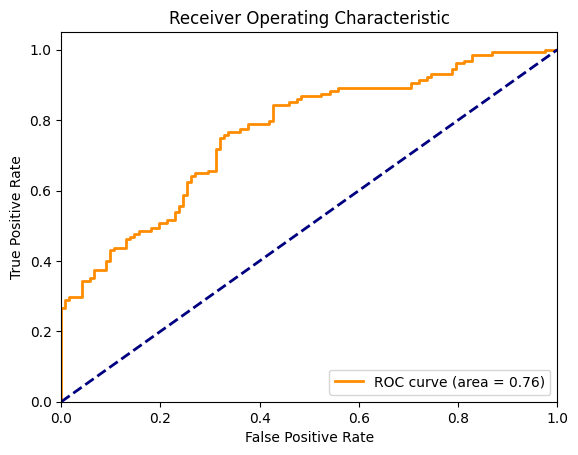

In [10]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Now Train XGBoost Model

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       122
           1       0.94      0.89      0.92       128

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



Out of the box, it gives us 89% recall which is pretty good but now my business manager becomes greedy and asks for 92% recall.

In [12]:
probabilities_xgb = model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, probabilities_xgb)

fpr_xgb[:5], tpr_xgb[:5], thresholds_xgb[:5]

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672]),
 array([0.       , 0.0078125, 0.078125 , 0.078125 , 0.1328125]),
 array([       inf, 0.99996841, 0.99993539, 0.99991846, 0.99987686]))

In [13]:
area2 = auc(fpr_xgb, tpr_xgb)
area2

0.9505635245901639

### Plot ROC Curve for Logistic Regression and XGBoost Side by Side

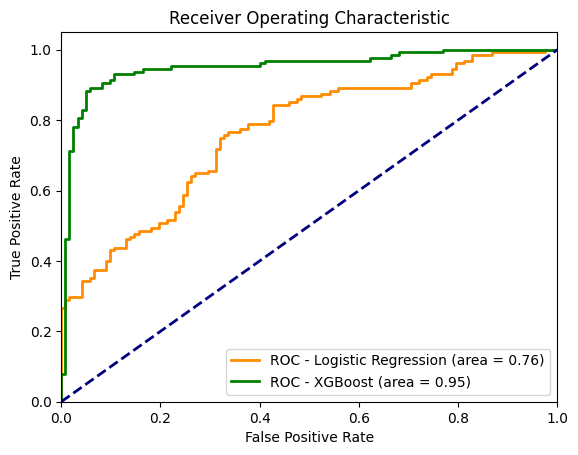

In [14]:
plt.figure()

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC - Logistic Regression (area = %0.2f)' % area)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='ROC - XGBoost (area = %0.2f)' % area2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [15]:
desired_recall = 0.92

closest_index = np.argmin(abs(tpr_xgb-desired_recall))
tpr_xgb[closest_index], thresholds_xgb[closest_index], fpr_xgb[closest_index]

(np.float64(0.9140625),
 np.float64(0.32361674308776855),
 np.float64(0.09836065573770492))

Threshold associated with 92% recall is 0.3, we will incorporate this in our inference code and deploy the model. Note that with this we will get a false positive rate of around 10% (0.098)

In [16]:
threshold = thresholds_xgb[closest_index]

y_pred_xgb = (probabilities_xgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       122
           1       0.91      0.91      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



# K Fold Cross Validation

### K-Fold Cross-Validation

**K-Fold** splits the data into **K parts** and trains/tests the model **K times**.

- Each time, one part is used for **testing**.
- The remaining parts are used for **training**.
- Finally, the scores are **averaged**.

**Example:** 5-Fold → 5 rounds of training and testing.

**Remember:** K-Fold = Split → Train/Test multiple times → Average the score.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=2, 
    random_state=42
)

# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [2]:
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.73      0.65      0.69       130
           1       0.66      0.74      0.70       120

    accuracy                           0.70       250
   macro avg       0.70      0.70      0.70       250
weighted avg       0.70      0.70      0.70       250



In [3]:
# kfold

from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)

In [4]:
#Example
for train_index, test_index in kf.split([50,60,70,80,90]):
    print(train_index,test_index)

[0 2 3 4] [1]
[0 1 2 3] [4]
[0 1 3 4] [2]
[1 2 3 4] [0]
[0 1 2 4] [3]


### K-Fold Train and Test Data

Suppose:

    train_index = [0, 2, 3, 4]
    test_index = [1]

Then:

    x_train = x[train_index]
    x_test  = x[test_index]

    y_train = y[train_index]
    y_test  = y[test_index]

**Example:**

    x_train = [20, 30, 35, 40]
    y_train = [0, 1, 0, 1]

    x_test  = [25]
    y_test  = [1]


In [5]:
scores=[]

for train_index, test_index in kf.split(x,y):
    x_train,x_test = x[train_index], x[test_index]
    y_train,y_test = y[train_index], y[test_index]

    model.fit(x_train, y_train)
    scores.append(model.score(x_test, y_test))

In [6]:
print("Cross-Validation Scores:", scores)

Cross-Validation Scores: [0.675, 0.715, 0.72, 0.645, 0.72]


In [7]:
# easy way to do cross validation using cross_val_score

from sklearn.model_selection import cross_val_score

cross_val_score(LogisticRegression(),x,y,cv=kf)

array([0.675, 0.715, 0.72 , 0.645, 0.72 ])

In [8]:
lr=cross_val_score(LogisticRegression(),x,y,cv=kf)
import numpy as np
np.average(lr)

np.float64(0.6950000000000001)

In [17]:
from sklearn.tree import DecisionTreeClassifier

Dt=cross_val_score(DecisionTreeClassifier(),x,y,cv=kf)

np.average(Dt)

np.float64(0.7929999999999999)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf=cross_val_score(RandomForestClassifier(n_estimators=20),x,y,cv=kf)

np.average(rf)

np.float64(0.8710000000000001)

In [19]:
rf=cross_val_score(RandomForestClassifier(n_estimators=30),x,y,cv=kf)

np.average(rf)

np.float64(0.882)

In [20]:
rf=cross_val_score(RandomForestClassifier(n_estimators=30),x,y,cv=kf,scoring="accuracy")

np.average(rf)

np.float64(0.8859999999999999)

In [22]:
# cross_validate

from sklearn.model_selection import cross_validate

cross_validate(DecisionTreeClassifier(),x,y,cv=kf,scoring=["accuracy","roc_auc"])

{'fit_time': array([0.00643611, 0.00579381, 0.00549197, 0.00574923, 0.00528264]),
 'score_time': array([0.00736785, 0.00355387, 0.0031004 , 0.00372028, 0.00297976]),
 'test_accuracy': array([0.725, 0.825, 0.77 , 0.82 , 0.825]),
 'test_roc_auc': array([0.722501  , 0.82402961, 0.77170868, 0.8213141 , 0.82767965])}

# Stratified K Fold Cross Validation

### Stratified K-Fold Cross-Validation

Suppose we have **10 emails**:
- 6 No Spam
- 4 Spam

With **2 folds**, Stratified K-Fold keeps the same class proportion in each fold:

    Fold 1 → 2 Spam + 3 No Spam
    Fold 2 → 2 Spam + 3 No Spam

This helps **avoid class imbalance** between the folds.

**Remember:** Stratified K-Fold = K-Fold + maintains class proportion.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=2, 
    weights = [0.9, 0.1],
    random_state=42
)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [33]:
from collections import Counter
Counter(y_test)  # class imbalance

Counter({np.int64(0): 266, np.int64(1): 34})

In [34]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)

In [35]:
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(Counter(y_test))    

Counter({np.int64(0): 177, np.int64(1): 23})
Counter({np.int64(0): 179, np.int64(1): 21})
Counter({np.int64(0): 183, np.int64(1): 17})
Counter({np.int64(0): 181, np.int64(1): 19})
Counter({np.int64(0): 177, np.int64(1): 23})


In [36]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(Counter(y_test))    

Counter({np.int64(0): 180, np.int64(1): 20})
Counter({np.int64(0): 180, np.int64(1): 20})
Counter({np.int64(0): 179, np.int64(1): 21})
Counter({np.int64(0): 179, np.int64(1): 21})
Counter({np.int64(0): 179, np.int64(1): 21})


In [37]:
from sklearn.model_selection import cross_val_score

cross_val_score(LogisticRegression(), X, y, cv=skf, scoring="accuracy")

array([0.915, 0.91 , 0.895, 0.895, 0.895])

# Hyperparameter Tuning: GridsearchCV

## GridSearchCV

**GridSearchCV** is used to find the **best hyperparameters** for a machine learning model.

### Simple Example

Suppose we have a Random Forest:

```python
RandomForestClassifier()
```

We want to find the best:

```text
n_estimators = 50, 100, 200
max_depth    = 3, 5, 10
```

GridSearchCV tries **all combinations**:

```text
50, 3
50, 5
50, 10
100, 3
100, 5
100, 10
200, 3
200, 5
200, 10
```

For each combination, it uses **Cross-Validation** and checks the model's performance.

Finally, it selects the combination with the **best score**.

### Code

```python
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.predict(x_test)
```

### Easy Flow

```text
Different Parameters
        ↓
Try all combinations
        ↓
Cross-Validation
        ↓
Compare Scores
        ↓
Best Parameters
        ↓
Best Model
```

### Remember

**GridSearchCV = Try different parameter combinations → find the best one.**

`cv=5` means the training data is divided into **5 parts** and cross-validation is performed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=2, 
    random_state=42
)

### Method 1: Evaluate the model using train, test split and tune parameters by trial and error

In [2]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = DecisionTreeClassifier(criterion="entropy", max_depth=10) # criteria: "gini" or "entropy", max_depth=5 or 10
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.75      0.80       130
           1       0.76      0.86      0.81       120

    accuracy                           0.80       250
   macro avg       0.81      0.81      0.80       250
weighted avg       0.81      0.80      0.80       250



### Method 2: Use K Fold Cross Validation

In [3]:
from sklearn.model_selection import cross_val_score

cross_val_score(DecisionTreeClassifier(criterion="gini", max_depth=5), X, y, cv=5)

array([0.775, 0.8  , 0.75 , 0.795, 0.775])

In [4]:
from sklearn.model_selection import cross_val_score

cross_val_score(DecisionTreeClassifier(criterion="gini", max_depth=10), X, y, cv=5)

array([0.77 , 0.72 , 0.81 , 0.79 , 0.815])

In [5]:
from sklearn.model_selection import cross_val_score

cross_val_score(DecisionTreeClassifier(criterion="entropy", max_depth=5), X, y, cv=5)

array([0.765, 0.785, 0.755, 0.815, 0.78 ])

## Method 3: Use GridSearchCV

### `return_train_score=False`

`False` → does **not calculate/store training scores**.

Only the **validation/test scores** are stored.

Example:

    return_train_score=False
    → mean_test_score = 0.78

    return_train_score=True
    → mean_train_score = 0.95
    → mean_test_score = 0.784

In [9]:
from sklearn.model_selection import GridSearchCV

clf=GridSearchCV(
    DecisionTreeClassifier(),
    {
        "criterion":["gini","entropy"], #2 parameters
        "max_depth":[5,10,15]          #3 parameters  so 2*3=6 its creaates 6 model
    },
    cv=5,
    return_train_score=False
)
clf.fit(X,y)
clf.cv_results_

{'mean_fit_time': array([0.00477061, 0.00593452, 0.00665588, 0.00694017, 0.01154876,
        0.01255817]),
 'std_fit_time': array([0.00018776, 0.00085111, 0.00022239, 0.00083825, 0.00112015,
        0.00298174]),
 'mean_score_time': array([0.00113487, 0.00110493, 0.00121508, 0.00105729, 0.00123363,
        0.00127411]),
 'std_score_time': array([0.00011447, 0.00022131, 0.00019576, 0.00014744, 0.00013668,
        0.00028459]),
 'param_criterion': masked_array(data=['gini', 'gini', 'gini', 'entropy', 'entropy',
                    'entropy'],
              mask=[False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'param_max_depth': masked_array(data=[5, 10, 15, 5, 10, 15],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'criterion': 'gini', 'max_depth': 5},
  {'criterion': 'gini', 'max_depth': 10},
  {'criterion': 'gini', 'max_depth': 15},
  {'criterion': 'entropy', 'max_depth': 5

In [10]:
df=pd.DataFrame(clf.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004771,0.000188,0.001135,0.000114,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.780,0.810,0.740,0.795,0.775,0.780,0.023452,6
1,0.005935,0.000851,0.001105,0.000221,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.795,0.705,0.825,0.800,0.805,0.786,0.041761,4
2,0.006656,0.000222,0.001215,0.000196,gini,15,"{'criterion': 'gini', 'max_depth': 15}",0.805,0.730,0.810,0.810,0.830,0.797,0.034583,2
3,0.006940,0.000838,0.001057,0.000147,entropy,5,"{'criterion': 'entropy', 'max_depth': 5}",0.765,0.785,0.760,0.815,0.790,0.783,0.019647,5
4,0.011549,0.001120,0.001234,0.000137,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.770,0.805,0.805,0.775,0.800,0.791,0.015297,3
5,0.012558,0.002982,0.001274,0.000285,entropy,15,"{'criterion': 'entropy', 'max_depth': 15}",0.780,0.810,0.810,0.810,0.855,0.813,0.024000,1


In [11]:
df[["param_criterion", "param_max_depth", "mean_test_score"]]

,param_criterion,param_max_depth,mean_test_score
0,gini,5,0.780
1,gini,10,0.786
2,gini,15,0.797
3,entropy,5,0.783
4,entropy,10,0.791
5,entropy,15,0.813


In [ ]:
clf.best_params_ # best entropy

{'criterion': 'entropy', 'max_depth': 15}

In [22]:
clf.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [23]:
model = clf.best_estimator_
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [24]:
p=X[0]
model.predict([p])

array([1])

In [21]:
y[0]

np.int64(1)

In [33]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

model_paras={
    "decision_tree":{
        "model":DecisionTreeClassifier(),
        "params":{
            "criterion":["gini","entropy"],
            "max_depth":[5,10,15]
        }
    },
    "svm":{
        "model":SVC(gamma="auto"),
        "params":{
            "C":[1,10,20],
            "kernel":["rbf","linear"]
        }
    }
}

scores=[]

for key , val in model_paras.items():
    clf=GridSearchCV(val["model"],val["params"],cv=5,return_train_score=False)
    clf.fit(X,y)
    scores.append({
        "model":key,
        "best_score":clf.best_score_,
        "best_params":clf.best_params_
    })

   

In [34]:
pd.DataFrame(scores)

,model,best_score,best_params
0,decision_tree,0.815,"{'criterion': 'entropy', 'max_depth': 15}"
1,svm,0.926,"{'C': 1, 'kernel': 'rbf'}"


# Hyperparameter Tuning: RandomizedSearchCV

## RandomizedSearchCV

`RandomizedSearchCV` is used to find the **best hyperparameters** of a machine learning model.

Instead of trying **every possible combination** like `GridSearchCV`, it randomly selects a specified number of combinations.

### Example

Suppose we have:

- `n_estimators = [50, 100, 200]`
- `max_depth = [3, 5, 10]`

There are:

**3 × 3 = 9 possible combinations**

If we use `n_iter=4`, `RandomizedSearchCV` randomly selects **4 combinations** from these 9 and tests them.

It uses **cross-validation (`cv`)** to evaluate each combination and selects the one with the **best score**.

### Code

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    n_iter=4,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X_train, y_train)

### Important Parameters

| Parameter | Meaning | Example |
|---|---|---|
| `param_grid` | Hyperparameters to try | `{"max_depth": [3, 5, 10]}` |
| `n_iter` | Number of random combinations to try | `n_iter=4` |
| `cv` | Number of cross-validation folds | `cv=5` |
| `scoring` | Metric used to compare models | `scoring="accuracy"` |
| `random_state` | Makes the random selection reproducible | `random_state=42` |

### GridSearchCV vs RandomizedSearchCV

**GridSearchCV** → Tries **all combinations**.

**RandomizedSearchCV** → Tries **randomly selected combinations**.

Therefore, `RandomizedSearchCV` can be **faster when there are many hyperparameter combinations**.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=2, 
    random_state=42
)

In [47]:
from sklearn.model_selection import RandomizedSearchCV

clf=RandomizedSearchCV(
    DecisionTreeClassifier(),
    {
        "criterion":["gini","entropy"], #2 parameters
        "max_depth":[5,10,15]          #3 parameters  so 2*3=6 its creaates 6 model
    },
    cv=5,
    return_train_score=False,
    n_iter=3 # ur are giving 3 so it selects random parameters and train only 3 models
)

clf.fit(X,y)
df=pd.DataFrame(clf.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005456,0.000555,0.000889,0.000192,15,gini,"{'max_depth': 15, 'criterion': 'gini'}",0.77,0.730,0.805,0.795,0.800,0.780,0.027749,2
1,0.008048,0.000422,0.000639,0.000019,15,entropy,"{'max_depth': 15, 'criterion': 'entropy'}",0.76,0.800,0.850,0.785,0.865,0.812,0.039573,1
2,0.003368,0.000154,0.000554,0.000076,5,gini,"{'max_depth': 5, 'criterion': 'gini'}",0.78,0.785,0.755,0.795,0.775,0.778,0.013266,3


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    n_iter=4,
    cv=5,
    scoring="accuracy"  
)
#If you don't give scoring, scikit-learn uses the estimator's default .score() method. 
# For RandomForestClassifier, .score() = accuracy.
random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 

In [49]:
pd.DataFrame(random_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.414622,0.030746,0.015102,0.000322,200,10,"{'n_estimators': 200, 'max_depth': 10}",0.885,0.860,0.910,0.915,0.88,0.890,0.020248,1
1,0.349951,0.033810,0.013790,0.000116,200,5,"{'n_estimators': 200, 'max_depth': 5}",0.830,0.835,0.855,0.865,0.83,0.843,0.014353,3
2,0.073602,0.000940,0.004099,0.000086,50,3,"{'n_estimators': 50, 'max_depth': 3}",0.770,0.765,0.715,0.805,0.76,0.763,0.028740,4
3,0.097382,0.000948,0.004504,0.000121,50,10,"{'n_estimators': 50, 'max_depth': 10}",0.875,0.865,0.895,0.885,0.87,0.878,0.010770,2
